<center><h1>Chen_Jessica_HW2</h1></center>
<br>
<br>

Name: Jessica Chen
<br>
Github Username: jc6006
<br>
USC ID: 9760667304

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from itertools import combinations

Get the Cycle Power Plant Data Set

In [128]:
df=pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")

### (b) Exploring the data

#### i. rows and columns

In [129]:
rows,cols=df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 9568
Columns: 5


Rows are each data point collected from a Combined Cycle Power Plant over 6 years (2006-2011) when the power plant was set to work with full load.
Columns are AT (temperature), AP (ambient pressure), RH (relative humidity), V (exhaust vacuum), and PE (energy output).

#### ii. pairwise scatterplots of all the varianbles

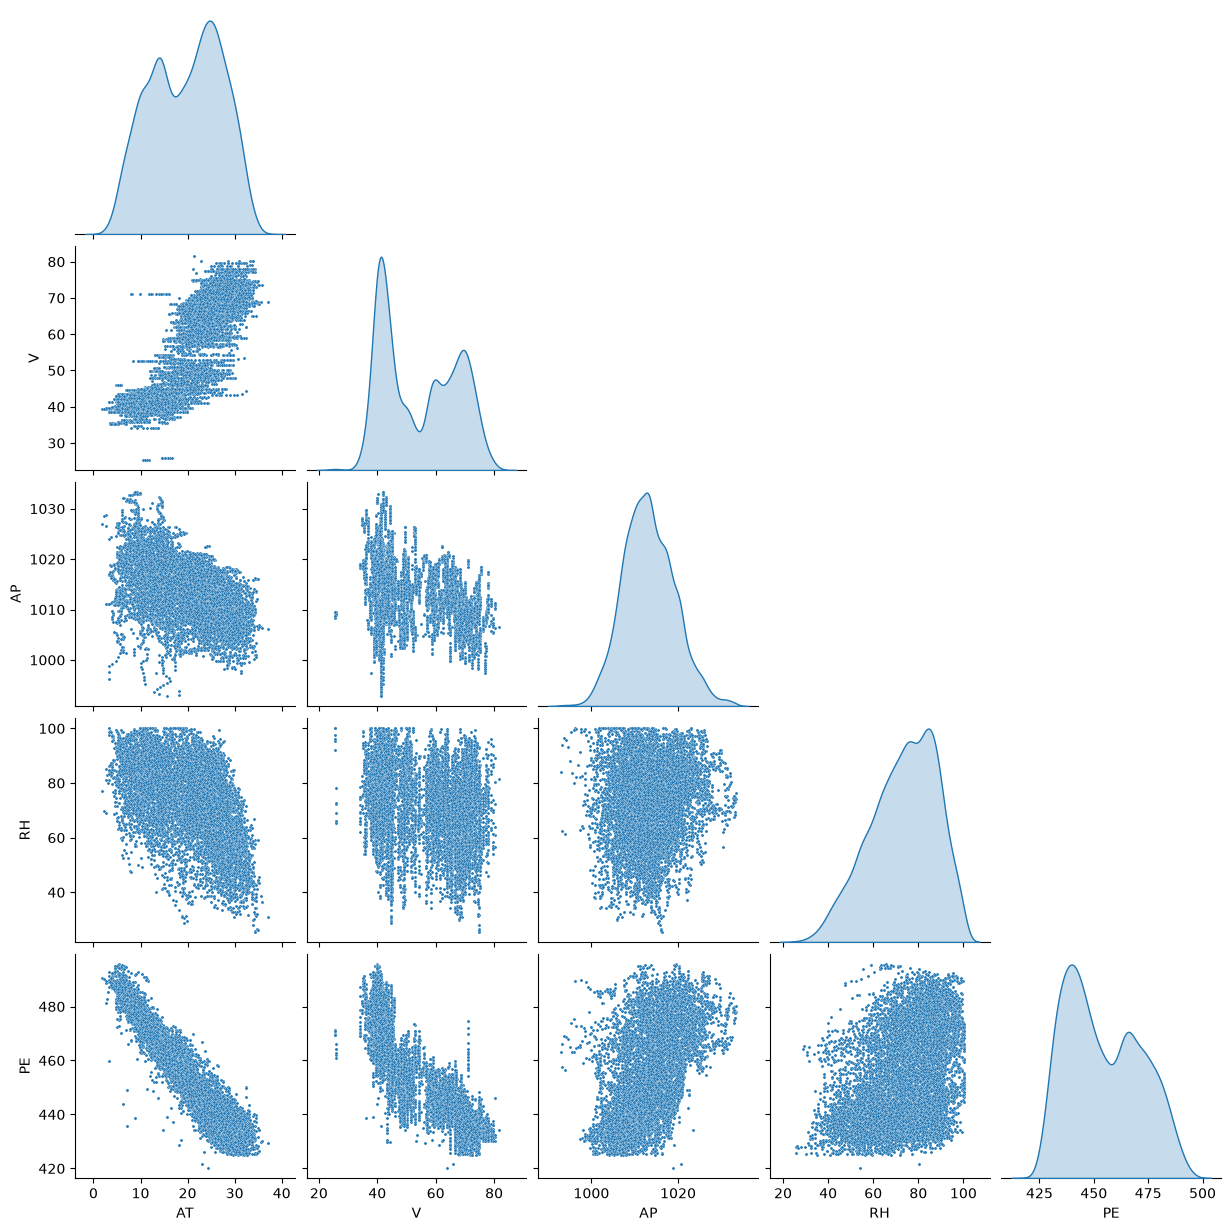

In [130]:
plot=sns.pairplot(df,corner=True,diag_kind="kde",plot_kws={"s":5})
plt.grid(True)
plt.show()

AT(temperature) & PE(energy output) are very strongly correlated (negatively linear). As temperature increases, energy output decreases. Weaker but also still mostly negatively linear relationships are V(exhaust vacuum) & PE, AT & RH(relative humidity). AT & RH and V & RH are weakly negatively linearly correlated. AT & V are mostly positively linearly correlated; AP & PE and RH & PE are very weakly linearly correlated (pretty diffuse).

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [131]:
summary=pd.DataFrame({
    "mean":df.mean(),
    "median":df.median(),
    "range":df.max()-df.min(),
    "first quartile":df.quantile(0.25),
    "third quartile":df.quantile(0.75),
    "interquartile range":df.quantile(0.75)-df.quantile(0.25)
})
summary

,mean,median,range,first quartile,third quartile,interquartile range
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:12   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

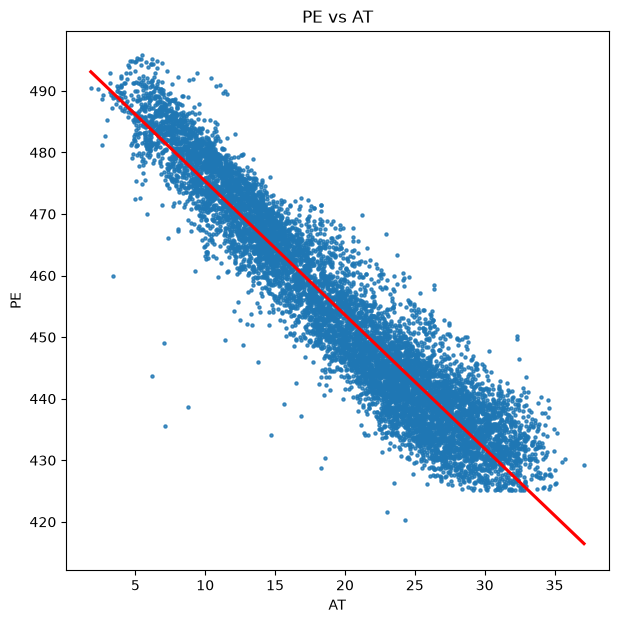

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:14   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

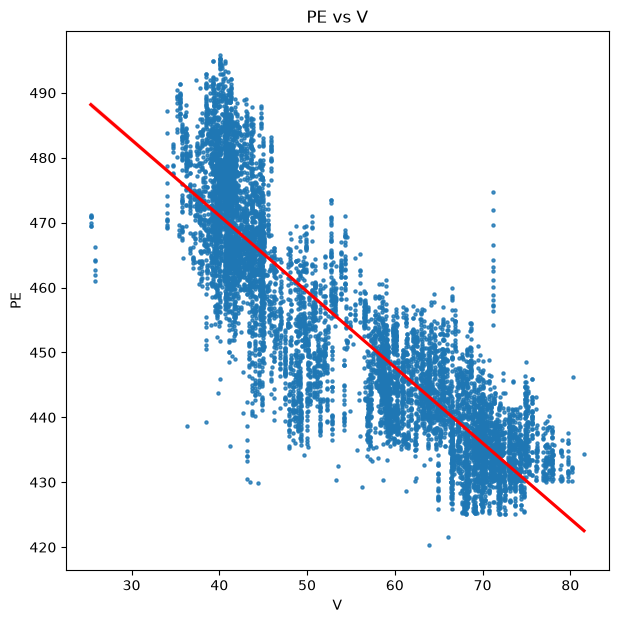

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:15   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

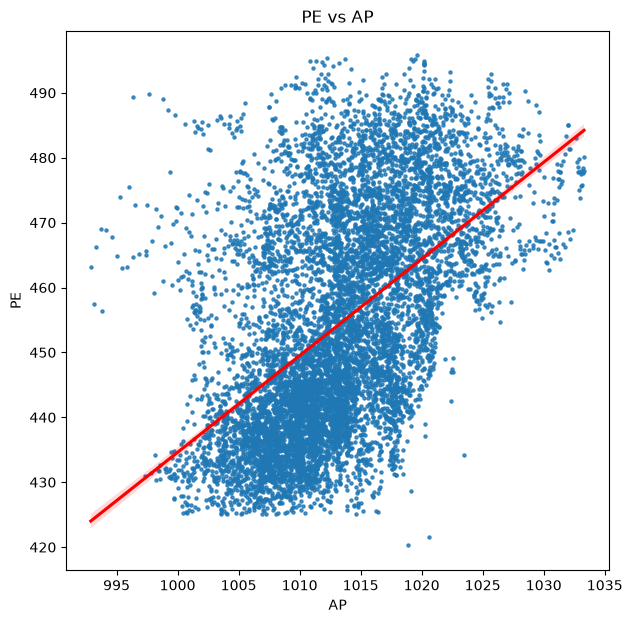

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:17   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

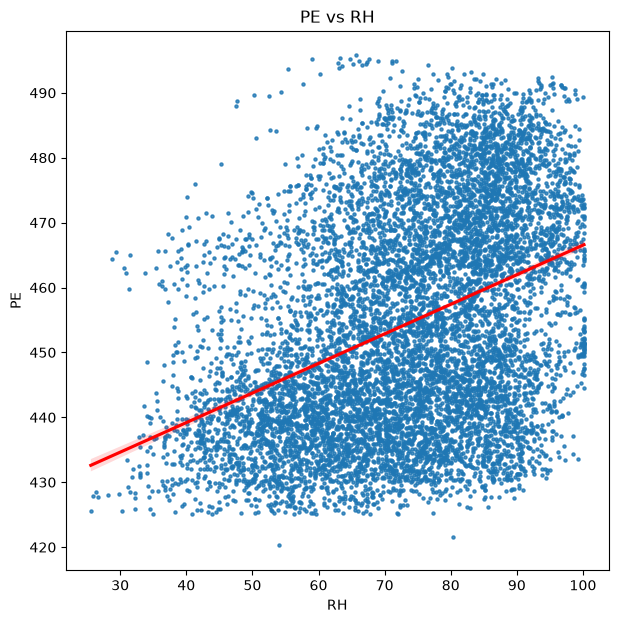

In [132]:
cols=["AT","V","AP","RH"]
y=df["PE"]
slr={}
for col in cols:
    x=sm.add_constant(df[col])
    model=sm.OLS(y,x).fit()
    slr[col]=model
    print(model.summary())
    print()
    plt.figure(figsize=(7,7))
    sns.regplot(x=col,y="PE",data=df,scatter_kws={"s":5},line_kws={"color":"red"})
    plt.title(f"PE vs {col}")
    plt.show()

All of them are statistically significant. I'd probably like to exclude V because it looks bimodal in the pairplot.

### (d) Multiple Regression

In [133]:
x=sm.add_constant(df[["AT","V","AP","RH"]])
mr=sm.OLS(y,x).fit()
print(mr.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:18   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

 Condition number is very large and indicates strong multicollinearity. AT is strongly negatively related, theothers have weaker effects. Reject null hypothesis for all of them (P>|t| is very close to 0).

### (e) 1c Compare to 1d

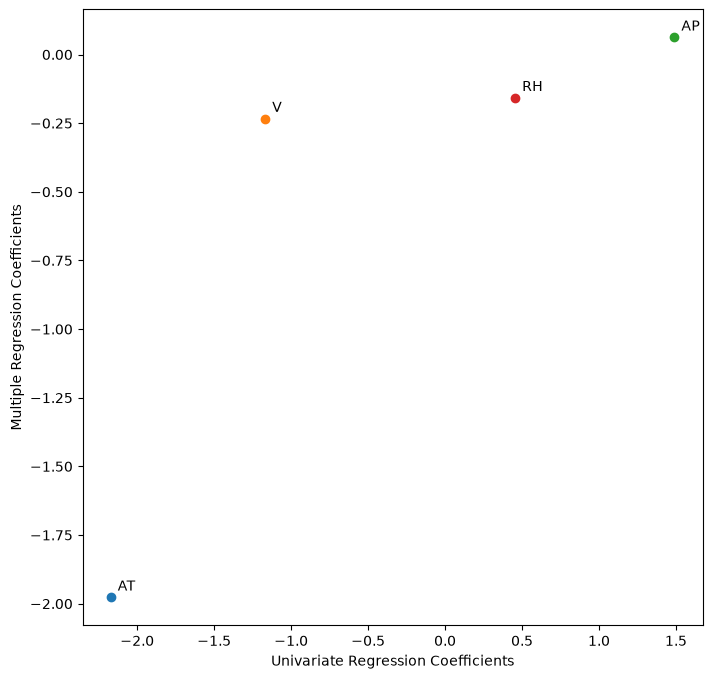

In [143]:
unicoef={col:slr[col].params[col] for col in cols}
multicoef={col:mr.params[col] for col in cols}
plt.figure(figsize=(8,8))
for col in cols:
    plt.scatter(unicoef[col],multicoef[col])
    plt.annotate(col,(unicoef[col],multicoef[col]),textcoords="offset points",xytext=(5, 5))
plt.xlabel("Univariate Regression Coefficients")
plt.ylabel("Multiple Regression Coefficients")
plt.show()

### (f) Nonlinear Association

In [135]:
na={}
for col in cols:
    centered_x=df[col]-df[col].mean()
    x=pd.DataFrame({col:centered_x,f"{col}^2":centered_x**2,f"{col}^3":centered_x**3})
    x=sm.add_constant(x)
    m=sm.OLS(y,x).fit()
    na[col]=m
    print(f"{col}")
    print(m.summary())
    print()

AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:19   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        452.7081      0.074   6085.240      

### (g) Interactions of Predictors

In [136]:
centered_df=df[cols]-df[cols].mean()
x=centered_df.copy()
for a,b in combinations(cols,2):
    x[f"{a}*{b}"]=centered_df[a]*centered_df[b]
x=sm.add_constant(x)
iop=sm.OLS(y,x).fit()
print(iop.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:03:20   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        452.6946      0.075   6074.393      0.0

ATxV, ATxRH, VxAP, and APxRH are all statistically significant (P>|t| < 0.05)

### (h) Improvement

In [137]:
train,test=train_test_split(df,test_size=0.3,random_state=42)
means=train[cols].mean()
dc_train=train[cols]-means
x_train=dc_train.copy()
for col in cols:
    x_train[f"{col}2"]=dc_train[col]**2
    x_train[f"{col}3"]=dc_train[col]**3
for a,b in combinations(cols, 2):
    x_train[f"{a}*{b}"]=dc_train[a]*dc_train[b]
x_train=sm.add_constant(x_train)
dc_test = test[cols]-means
x_test = dc_test.copy()
for col in cols:
    x_test[f"{col}2"]=dc_test[col]**2
    x_test[f"{col}3"]=dc_test[col]**3
for a,b in combinations(cols, 2):
    x_test[f"{a}*{b}"]=dc_test[a]*dc_test[b]
x_test=sm.add_constant(x_test,has_constant="add")
y_train,y_test=train["PE"],test["PE"]

not_significant=["RH3","V*AP","V*RH","AT*AP"]
improved_x_train=x_train.drop(columns=not_significant)
improved_x_test=x_test.drop(columns=not_significant)
improved_model=sm.OLS(y_train,improved_x_train).fit()
improved_train_mse=mean_squared_error(y_train,improved_model.predict(improved_x_train))
improved_test_mse=mean_squared_error(y_test,improved_model.predict(improved_x_test))
print(f"Improved Train MSE: {improved_train_mse:.3f}   Test MSE: {improved_test_mse:.3f}   R²: {improved_model.rsquared:.4f}")

starting_model=sm.OLS(y_train,x_train).fit()
mse_train=mean_squared_error(y_train,starting_model.predict(x_train))
mse_test=mean_squared_error(y_test,starting_model.predict(x_test))
print(f"Train MSE: {mse_train:.3f}   Test MSE: {mse_test:.3f}   R²: {starting_model.rsquared:.4f}")
#print(starting_model.pvalues.round(4)) used for seeing p values to drop insignificant ones for the improved model

Improved Train MSE: 17.576   Test MSE: 18.218   R²: 0.9395
Train MSE: 17.542   Test MSE: 18.179   R²: 0.9396


Dropping insignificant values doesn't shift the MSEs or R^2 by much so the simpler model is about as good.

### (i) KNN

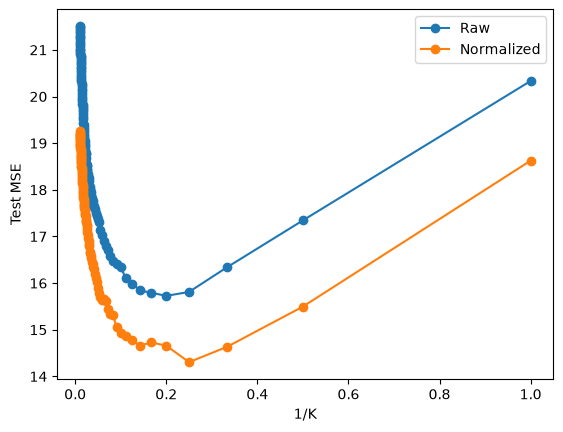

Best raw K: 5
Raw Test MSE: 15.726819842563568
Best normalized K: 4
Normalized Test MSE: 14.305669422675024


In [138]:
x=df[cols]
y=df["PE"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
scaler=StandardScaler().fit(x_train)
s_x_train=scaler.transform(x_train)
s_x_test=scaler.transform(x_test)
ks=list(range(1, 101))
raw_train_mse,raw_test_mse=[],[]
norm_train_mse,norm_test_mse=[],[]
for k in ks:
    knn_raw=KNeighborsRegressor(n_neighbors=k).fit(x_train,y_train)
    raw_train_mse.append(mean_squared_error(y_train,knn_raw.predict(x_train)))
    raw_test_mse.append(mean_squared_error(y_test,knn_raw.predict(x_test)))

    knn_norm=KNeighborsRegressor(n_neighbors=k).fit(s_x_train,y_train)
    norm_train_mse.append(mean_squared_error(y_train,knn_norm.predict(s_x_train)))
    norm_test_mse.append(mean_squared_error(y_test,knn_norm.predict(s_x_test)))
plt.plot([1/k for k in ks],raw_test_mse,marker="o",label="Raw")
plt.plot([1/k for k in ks],norm_test_mse,marker="o",label="Normalized")
plt.xlabel("1/K")
plt.ylabel("Test MSE")
plt.legend()
plt.show()
best_raw_k=ks[np.argmin(raw_test_mse)]
best_norm_k=ks[np.argmin(norm_test_mse)]
print(f"Best raw K: {best_raw_k}")
print(f"Raw Test MSE: {min(raw_test_mse)}")
print(f"Best normalized K: {best_norm_k}")
print(f"Normalized Test MSE: {min(norm_test_mse)}")

### (j ) Compare KNN and Linear

In [139]:
comparison=pd.DataFrame({
    "Model":["Linear Regression Model","KNN (raw)","KNN (normalized)"],
    "Test MSE":[mse_test,min(raw_test_mse),min(norm_test_mse)]
})
comparison

,Model,Test MSE
0,Linear Regression Model,18.178590
1,KNN (raw),15.726820
2,KNN (normalized),14.305669


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Better, due to the large n it'll have less bias but without overfitting, since p is small.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Worse, a rigid model would do better because the flexible model would overfit.

### (c) The relationship between the predictors and response is highly non-linear.

Better, non-linear means that a flexible model would be able to more closely fit to the actual pattern.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Worse, a rigid model would do better because the flexible model would incorporate too much error.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [140]:
df=pd.DataFrame({
    "Obs":[1,2,3,4,5,6],
    "X1":[0,2,0,0,-1,1],
    "X2":[3,0,1,1,0,1],
    "X3":[0,0,3,2,1,1],
    "Y":["Red","Red","Red","Green","Green","Red"]
})
df["Distance"]=np.sqrt(df["X1"]**2+df["X2"]**2+df["X3"]**2)
df

,Obs,X1,X2,X3,Y,Distance
0,1,0,3,0,Red,3.000000
1,2,2,0,0,Red,2.000000
2,3,0,1,3,Red,3.162278
3,4,0,1,2,Green,2.236068
4,5,-1,0,1,Green,1.414214
5,6,1,1,1,Red,1.732051


### (b) What is our prediction with K = 1? Why?

In [141]:
k1=df.iloc[4]["Y"]
print(f"Observation {df.iloc[4]['Obs']}")
print(f"Prediction: {k1}")

Observation 5
Prediction: Green


Observation 5 has the smallest distance and we're not looking at other neighbors so it's just green.

### (c) What is our prediction with K = 3? Why?

In [142]:
indx=df["Distance"].nsmallest(3).index
neighbors=df.loc[indx]
k3=neighbors["Y"].mode()[0]
print(neighbors[["Obs", "Distance", "Y"]])
print(f"Prediction: {k3}")

   Obs  Distance      Y
4    5  1.414214  Green
5    6  1.732051    Red
1    2  2.000000    Red
Prediction: Red


These are the observations with the smallest distances and there are 2 red to 1 green so it's red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

Small K, because a large K would make the decision boundary linear.